# Example: Explainable AI via Grad-CAM and LOTS

## 1. Introduction: Why Explainable AI?
Deep learning models, such as Convolutional Neural Networks (CNNs), often achieve impressive performance in image classification tasks. However, they are usually treated as "**black boxes**" — it is difficult to understand how they make their decisions.

**Explainable AI** (XAI) aims to illuminate these hidden processes by providing tools and methods to visualize and interpret model behavior.

In this example:

*  Our goal is to visualize the influential parts of the image that the network uses for its decision-making.

*  We apply two XAI techniques, Class Activation Mapping (**CAM**) and Layerwise Origin Target Synthesis (**LOTS**), to images classified by a **ResNet-50** network.
*  We compare two different perspectives: **CAM** and **LOTS**.


## 2. Load Example Image and Pre-trained Network

The (pre-trained) network we used is ResNet50, which can be obtained via functionality in the `torchvision` library: https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html

Since we cannot modify the network topology using a class definition, we make use of the flexibility of python, which allows reimplementing specific functions.
Particularly, we will reimplement the `_forward_impl` function (which is called in `forward`).
For the reference, the original implementation of the `_forward_impl` function is defined online: https://github.com/pytorch/vision/blob/61d97f41bc209e1407dcfbd685d2ee2da9c1cdad/torchvision/models/resnet.py#L266

### 2.1 Necessary Packages
Import libraries for image processing, neural network implementation and plotting.

Note: on local environments, you might need to install OpenCV via `conda install opencv`.

In [69]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import torch
from tqdm import tqdm
import cv2
import sys
import numpy as np
import torchvision
from matplotlib import pyplot

import pathlib
import urllib
import PIL.Image

### 2.2 Image Loading and Preprocessing

We load a sample image "hen.png" using `PIL.Image.open()` and plot this image by using `pyplot.imshow()`

Then we implement the image preprocessing steps which are required for the ResNet-50 network pre-trained on the ImageNet dataset.

After that, we apply this transform to the`pil_image` so that we get the input image for ResNet network.


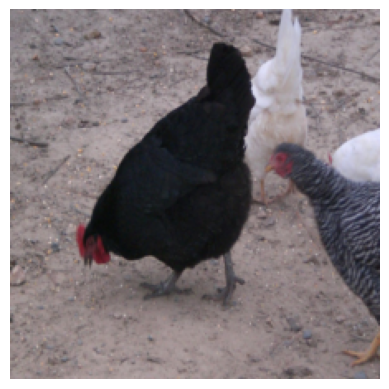

In [70]:
data_url = "https://seafile.ifi.uzh.ch/f/0feeb844277c48058ac9/?dl=1"
data_file = pathlib.Path("hen.png")

# Skip downloading if the file already exists
if not data_file.is_file():
    # Download the file
    urllib.request.urlretrieve(data_url, data_file)
    print(f"Downloaded {data_file} successfully.")

# filename = "hen.png"
target = 8

pil_image = PIL.Image.open(data_file)

# show image
pyplot.imshow(pil_image)
_ = pyplot.axis("off")

In [71]:
# define a transform
transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
])

# preprocess the image
scaled_image = transforms(pil_image)

### 2.3 Network Instantiation

Now, we instantiate a pre-trained ResNet-50 network -- the weights will be downloaded automatically.
To enable extraction of intermediate feature maps needed for CAM and LOTS, we override the network's internal `_forward_impl` function to return:


*   Feature maps from the last convolutional layer.

*   Deep features from the layer before the final classification layer.

*   Final logits (classification outputs).

Notes:

1. We move the Normalization (`norm`) into the network instead of keeping it in the transform preprocessing. This will allow gradients for LOTS to flow to the unnormalized image layer.
2. We manipulate the `_forward_impl` function such that it returns all required features.
3. We overwrite the function `_forward_impl` in the pre-trained network.

In [72]:
# instantiate pre-trained ResNet-50 network
resnet = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)

# add the image normalization as part of the network
resnet.norm = torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

# manipulate network to return the feature map and deep features
def _forward_impl(self, x):
    # apply the image normalization
    x = self.norm(x)
    # implement the forward processing in ResNet
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)

    # store intermediate representation of the feature map
    feature_map = x

    x = self.avgpool(x)
    x = torch.flatten(x, 1)

    # store intermediate representation of the deep features
    deep_features = x

    x = self.fc(x)

    # return all elements that we will need later on
    return x, feature_map, deep_features


# overwrite this function in the pre-trained network
import functools
resnet._forward_impl = functools.partial(_forward_impl, resnet)

Get outputs of example image and check the predictions.


In [73]:
# get the outputs
logits, feature_map, deep_features = resnet(scaled_image.unsqueeze(0))
# compute the probabilities
probabilities = torch.nn.functional.softmax(logits, dim=1)

print("The logit of the ground truth:", logits[0][target].item(), "with probability:", probabilities[0][target].item())

The logit of the ground truth: 0.29697734117507935 with probability: 0.0013154050102457404


In [74]:
top5_values, top5_indices = torch.topk(probabilities, k=5) # check the logtis and indexes of top 5

print("Top 5 values: ", top5_values.detach())
print("Top 5 indexes: ", top5_indices.detach())

Top 5 values:  tensor([[0.0023, 0.0023, 0.0022, 0.0022, 0.0021]])
Top 5 indexes:  tensor([[501, 469, 448, 462, 792]])


## 3. Class Activation Mapping from Pre-Trained Networks

We make use of the Grad-CAM technique as introduced in the lecture.

Let:


*   $z_o$ be the output logit (before softmax) for class $o$
*   $\mathbf A_q \in \mathbb{R}^{K \times M}$ be the $q$-th channel of the feature map.
*   $\alpha_q^o$ be the importance weight for the channel $q$ regarding class $o$.

#### Step 1: Compute weight $\alpha$
In Grad-CAM, we compute $$\alpha_q^o = \frac{1}{K \cdot M} \sum_{k, m} \frac{\partial z_o}{\partial \mathbf A_q(k, m)} = \frac{1}{K \cdot M} w_{o,q}$$
where $\alpha_q^o$ is the FC layer's weight connecting feature map to $q$ class $o$, and $w_q^o$ the weight of the final fully-connected layer in the network. 

The factor $\frac{1}{K \cdot M}$ arises from the global average pooling that is applied in the network.
However, since this is a constant, and in step 3 we normalize out such constants, we can ignore this factor and set $\alpha_q^o = w_{o,q}$.

#### Step 2: Compute the class activation map $\mathbf M_o$

The activation map for class $o$ can be computed as the weighted combination of feature maps:
$$\mathbf M_o = \max\left(\sum_{q} \alpha^o_q \mathbf A_q, 0\right)$$
This operation is applied pixel-wise.

Here we use `ReLU` to preserve positive influences.

#### Step 3: Normalize:
As a post-processing step, we need to resize $\mathbf M_o$ to match the input image size.
Also, we want to normalize the activation map to the range $[0,1]$ by dividing by its maximum value:
$$\mathbf M_o' = \frac{\mathbf M_o}{\max \mathbf M_o}$$

#### Step 4: Visualize:
Finally, we overlay it as a heatmap on the original image.
We rely on functionality of OpenCV to generate the heatmap.

### 3.1 CAM Implementation

<!-- Implement a function that computes the visualization mask $\mathbf M_o'$ for a given class $o$.
Make use of the elements of the network and feature maps.

Finally, multiply the activation map with the preprocessed input image to highlight the regions that are of importance to classify class $o$. -->

1. We implement a function that computes the visualization mask $\mathbf M_o'$ for a given class $o$.
2. We make use of the elements of the network and feature maps.
3. We normalize the activation map and resize it to the input size.

<!-- What do you need to consider in order to achieve this? -->

In [75]:
def class_activation_map(o, fm):
    # obtain the weights for class o alpha_q^o for all convolution channels q
    alpha = resnet.fc.weight[o]

    # compute the class activation map M_o as given above
    cam = torch.nn.functional.relu(torch.sum(fm[0] * alpha[:,None,None], axis=0)).detach()

    # normalize the activation map
    cam = cam / torch.max(cam)

    # multiply the map with the image
    cam = torchvision.transforms.Resize(224)(cam[None])[0].numpy()

    return cam

### 3.2 Visualization

Finally, we visualize the parts of the image used to predict class Hen (at index 8).
There are four figures needed to show:


*   The orignal activation map $M'_o$
*   Convert it into a color heatmap.




In [76]:
def get_heatmap(img,mask):

    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = np.float32(heatmap) / 255.

    # apply heatmap on the orignal image
    cam = (1 - 0.5) * heatmap + 0.5 * img
    cam = cam / np.max(cam)
    overlay = np.uint8(255 * cam)
    return overlay

Visualize the CAM result of the target.

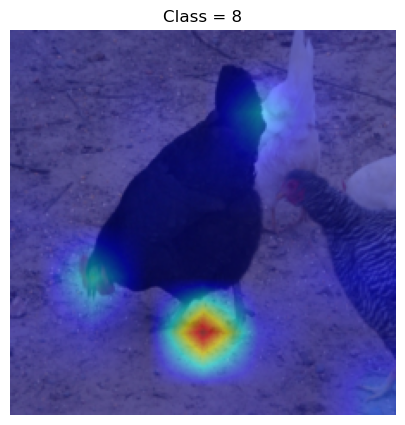

In [77]:
fig, axes = pyplot.subplots(1, 1, figsize=(10,5))

# visualize the class hock
act_map = class_activation_map(target,feature_map)
heatmap_cam = get_heatmap(scaled_image.detach().numpy().transpose(1, 2, 0), act_map)
axes.set_title("Class = " + str(target))
axes.imshow(heatmap_cam)
axes.axis("off")
fig.savefig("CAM_class=8.pdf")


Visualize the CAM results of the top 5 predictions.

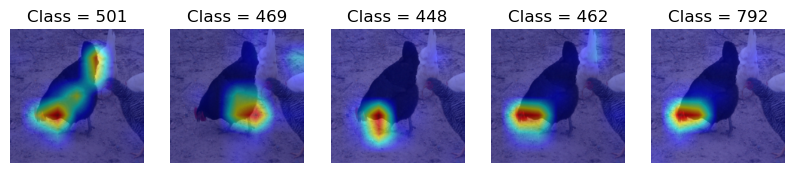

In [78]:
fig, axes = pyplot.subplots(1, 5, figsize=(10,5))
index=0
for predict_target in top5_indices[0]:
  current_cam = class_activation_map(predict_target,feature_map)
  overlay = get_heatmap(scaled_image.numpy().transpose(1, 2, 0), current_cam)
  axes[index].imshow(overlay)
  axes[index].axis("off")
  axes[index].set_title("Class = " + str(predict_target.item()))
  index += 1
fig.savefig("CAM_top5.pdf")


## 4. Layerwise Origin Target Synthesise (LOTS)

Instead of relying on class-specific gradients (like CAM), LOTS focuses on the sensitivity of deep representations. It shows which pixels are most responsible for shaping the network's internal "understanding" of the input.

Originally developed for generating adversarial examples, LOTS has been adapted into an XAI method by observing how image perturbations affect feature representations.

Let:
<!-- $\check{\vec{\varphi}}$

$\check{\mathcal{X}}$ -->

*   $ \mathcal{X} $ be the orignal input image.
*   $\vec\varphi \in \mathbb{R}^d$ be the deep feature vector from some layer (here we use the deep feature layer) of the network.
*   $\check{\vec{\varphi}} \in \mathbb{R}^d$ be the target deep features that you want $\vec{\varphi}$ to match.

#### Step 1: Define Target Features
We set $\check{\vec{\varphi}}=0$ (zero vector).
Alternatively, $\check{\vec{\varphi}}$ can come from another image (for adversarial attacks).

#### Step 2: Minimize Feature Distance
Measure the difference between current features $\vec{\varphi}$ and the target features $\check{\vec{\varphi}}$, here we can use Euclidean distance:
$$\mathcal{J} = ||\vec{\varphi} - \check{\vec{\varphi}} ||^2$$

#### Step 3: Gradient-based Optimization
Now, we calculate Gradient w.r.t input.
$$\nabla_\mathcal{X} \mathcal{J} = \frac{\partial \mathcal{J}}{\partial \mathcal{X}}$$
We take a small step in the negative gradient direction and update **the input**:
$$\check{\mathcal{X}} \leftarrow \mathcal{X} - \eta \cdot \frac{\nabla_x \mathcal{J}}{\max \left| \nabla_x \mathcal{J} \right|}$$
We repeat the update until the distance between $\check{\vec{\varphi}}$ and $\vec{\varphi}$ is below a set threshold $\epsilon$, or the maximum number of iterations is reached.

#### Step 4: Visualization:

Given the original image $\mathcal{X}$ and one adversarial image $\check{\mathcal{X}}$:
* Step 1: Compute the pixel-wise difference between the original image and the final adversarial image.

* Step 2: Take the absolute value and convert it to grayscale.

* Step 3: Apply Gaussian blur so that we can get the perturbation map.

* Step 4: Use the above function for visualization

### 4.1 LOTS Implementation Details


In [79]:
def lots(network, data, target, epsilon, eta, iterations):

    # iterate for the given number of iterations
    img = data.clone()
    img.requires_grad_(True)
    for iteration in tqdm(range(iterations), file=sys.stdout, desc="LOTS"):
        network.zero_grad()
        # forward image and extract the given layer and the logits
        logits, fm, features = network(img)
        with torch.no_grad():
            # check if we are close enough to our target
            # this is not used in our small example but only given as possible success criterion
            if epsilon is not None and torch.norm(features - target) < epsilon:
                break

        # compute MSE loss between output and target
        J = torch.nn.functional.mse_loss(features, target, reduction="sum")

        # get gradient
        J.backward()
        gradient = img.grad.detach()
        img.grad = None

        with torch.no_grad():
            # normalize gradient to have its max abs value at 1
            gradient_step = gradient / torch.max(torch.abs(gradient))

            # reduce loss by moving toward negative gradient
            img -= eta * gradient_step

    return img.detach().squeeze(0)

Here we use a **zero vector** with the same dimension of deep features as the target features.


In [80]:
target_features = torch.zeros(deep_features.shape)

adversarial_image = lots(
            network=resnet,
            data=scaled_image[None, ...],
            target=target_features,
            iterations=100,
            epsilon=0.1,
            eta=5.0 / 255.0,
        )

LOTS: 100%|██████████| 100/100 [00:26<00:00,  3.79it/s]


### 4.2. Visualization


*   Convert both original and adversarial images to grayscale.

*   Take the absolute difference between them.

*   Normalize this difference to the [0, 1] range.



In [81]:
# compute the difference between adversarial_img and original_img
def get_difference(adversarial_img, original_img):
    # convert both to grayscale
    tf =  torchvision.transforms.Grayscale(num_output_channels=1)
    adversarial_img_gray = tf(adversarial_img)
    original_img_gray = tf(original_img)

    # compute the absolute difference between adversarial and original image
    diff = abs(adversarial_img_gray - original_img_gray)

    # Normalize the values between min & max
    diff_norm = (diff - diff.min()) / (diff.max() - diff.min() + 1e-8)

    return diff_norm

diff_norm = get_difference(adversarial_image, scaled_image)



*   Apply Gaussian Smoothing



In [82]:
def lots_visualization(diff_img, filter_size):

    diff_img = diff_img.squeeze(0)
    # Create an empty tensor of the same shape as diff_img
    pert_img = torch.zeros(diff_img.shape)

    # Apply Gaussian blur by using cv2.GaussianBlur
    med_vis = cv2.GaussianBlur(diff_img.numpy(), (filter_size, filter_size), 0)

    # Apply the maximum normalization
    med_vis_normalized = med_vis / med_vis.max()

    # Convert the processed array back to a torch tensor
    pert_img = torch.tensor(med_vis_normalized)

    # Return the resulting tensor
    return pert_img

filter_size = 49
pert_img = lots_visualization(diff_norm, filter_size)

Finally, we create a colorful heatmap better visualization, and compare visualizations of CAM and LOTS

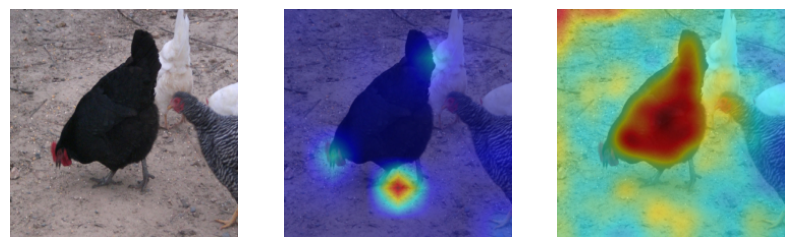

In [83]:
# get the LOTS heatmap
heatmap_lots = get_heatmap(scaled_image.numpy().transpose(1, 2, 0), pert_img)

# show comparison plot
fig, axes = pyplot.subplots(1, 3, figsize=(10,5))

axes[0].imshow(scaled_image.detach().permute(1,2,0))
axes[0].axis("off")

axes[1].imshow(heatmap_cam)
axes[1].axis("off")

axes[2].imshow(heatmap_lots)
axes[2].axis("off")
fig.savefig("Visualization.pdf")

## 🔍 Comparison: CAM vs LOTS

### 🟦 CAM (Class Activation Mapping)

**✅ Pros:**
- Provides **class-specific** visual explanations.
- Simple and efficient — only requires a **single (partial) backward pass**.
- Ideal for classification tasks where **class labels are available**.

**❌ Cons:**
- Requires **knowledge of the target class**.
- Only highlights **positive influences** (due to ReLU).
- Limited to certain architectures unless extended (e.g., Grad-CAM++)
- The final result is upscaled to input size.

---

### 🟨 LOTS (Layerwise Origin Target Synthesis)

**✅ Pros:**
- **Class-agnostic** — does not require labels.
- Captures **fine-grained sensitivity** in deep feature space.
- Can be applied to **any internal layer** of the network and any different network architectures.

**❌ Cons:**
- **More computationally expensive** — requires iterative optimization.
- Sensitive to **hyperparameters** (step size, iterations, target).
- Needs **post-processing** (e.g., Gaussian smoothing).
